<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Crossformer_Rockfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 148.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pyt

In [1]:
# Codeblock Q001: Clone Crossformer repository
!git clone https://github.com/thinklab-sjtu/crossformer.git
%cd crossformer

fatal: destination path 'crossformer' already exists and is not an empty directory.
/content/crossformer


In [2]:
# Codeblock Q002: Install modern, Colab-compatible dependencies
!pip install einops numpy pandas torch

In [3]:
# Codeblock Q003: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Codeblock Q004: Load Rockfall XLSX from Google Drive
import pandas as pd

xlsx_path = "/content/drive/MyDrive/Masters_Colab_Data/Model_Ready_Imputed_Rockfall_Data.xlsx"
df = pd.read_excel(xlsx_path)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Datetime                     8760 non-null   datetime64[ns]
 1   Air_Temp_Real                8760 non-null   int64         
 2   Air_Temp_Kalman              8760 non-null   float64       
 3   Relative_Humidity_Real       8760 non-null   int64         
 4   Relative_Humidity_Kalman     8760 non-null   float64       
 5   Hourly_Rainfall_Real         8760 non-null   int64         
 6   Hourly_Rainfall_Kalman       8760 non-null   float64       
 7   TA_Real                      8760 non-null   int64         
 8   TA_Kalman                    8760 non-null   float64       
 9   Tmean_Real                   8760 non-null   int64         
 10  Tmean_Kalman                 8760 non-null   float64       
 11  Tmin_Real                    8760 non-null 

In [5]:
# Codeblock Q005: Generate Timestamp and save clean CSV
df["timestamp"] = df["Datetime"].astype(str)
df = df.drop(columns=["Datetime"])

# Move timestamp to the first column
cols = ["timestamp"] + [c for c in df.columns if c != "timestamp"]
df = df[cols]

df.info()

df.to_csv("./datasets/Model_Ready_Imputed_Rockfall_Data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    8760 non-null   object 
 1   Air_Temp_Real                8760 non-null   int64  
 2   Air_Temp_Kalman              8760 non-null   float64
 3   Relative_Humidity_Real       8760 non-null   int64  
 4   Relative_Humidity_Kalman     8760 non-null   float64
 5   Hourly_Rainfall_Real         8760 non-null   int64  
 6   Hourly_Rainfall_Kalman       8760 non-null   float64
 7   TA_Real                      8760 non-null   int64  
 8   TA_Kalman                    8760 non-null   float64
 9   Tmean_Real                   8760 non-null   int64  
 10  Tmean_Kalman                 8760 non-null   float64
 11  Tmin_Real                    8760 non-null   int64  
 12  Tmin_Kalman                  8760 non-null   float64
 13  Tmax_Real         

In [6]:
# Codeblock Q006: Train Crossformer using XLSX-derived dataset
!python main_crossformer.py \
  --data Rockfall \
  --data_path Model_Ready_Imputed_Rockfall_Data.csv \
  --data_dim 38 \
  --in_len 168 \
  --out_len 24 \
  --seg_len 6  \
  --train_epochs 100 \
  --patience 5

Args in experiment:
Namespace(data='Rockfall', root_path='./datasets/', data_path='Model_Ready_Imputed_Rockfall_Data.csv', data_split=[0.7, 0.1, 0.2], checkpoints='./checkpoints/', in_len=168, out_len=24, seg_len=6, win_size=2, factor=10, data_dim=38, d_model=256, d_ff=512, n_heads=4, e_layers=3, dropout=0.2, baseline=False, num_workers=0, batch_size=32, train_epochs=100, patience=5, learning_rate=0.0001, lradj='type1', itr=1, save_pred=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3')
Use GPU: cuda:0
>>>>>>>start training : Crossformer_Rockfall_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 5941
val 853
test 1729
	iters: 100, epoch: 1 | loss: 0.6250992
	speed: 0.0496s/iter; left time: 917.5183s
Epoch: 1 cost time: 8.57853627204895
Epoch: 1, Steps: 186 | Train Loss: 0.7140003 Vali Loss: 1.8766659 Test Loss: 0.4831599
Validation loss decreased (inf --> 1.876666).  Saving model ...
	iters: 100, epoch: 2 | loss: 0.4882368
	speed: 0.0408s/iter

In [7]:
# Codeblock Q007: Evaluate using GitHub scripts

!python eval_crossformer.py \
  --setting_name Crossformer_Rockfall_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0 \
  --save_pred

Use GPU: cuda:0
mse:0.49849310517311096, mae:0.47888094186782837


In [8]:
# Codeblock Q008: Define Predicted and True Shapes

import numpy as np

setting = "Crossformer_Rockfall_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0"

pred = np.load(f'./results/{setting}/pred.npy')
true = np.load(f'./results/{setting}/true.npy')

pred.shape, true.shape

((1729, 24, 38), (1729, 24, 38))

In [9]:
# Codeblock Q009: Report Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(true.flatten(), pred.flatten())
mse = mean_squared_error(true.flatten(), pred.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((true - pred) / true)) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.47888097167015076
MSE: 0.4984932839870453
RMSE: 0.7060405682303569
MAPE: 228.16197872161865


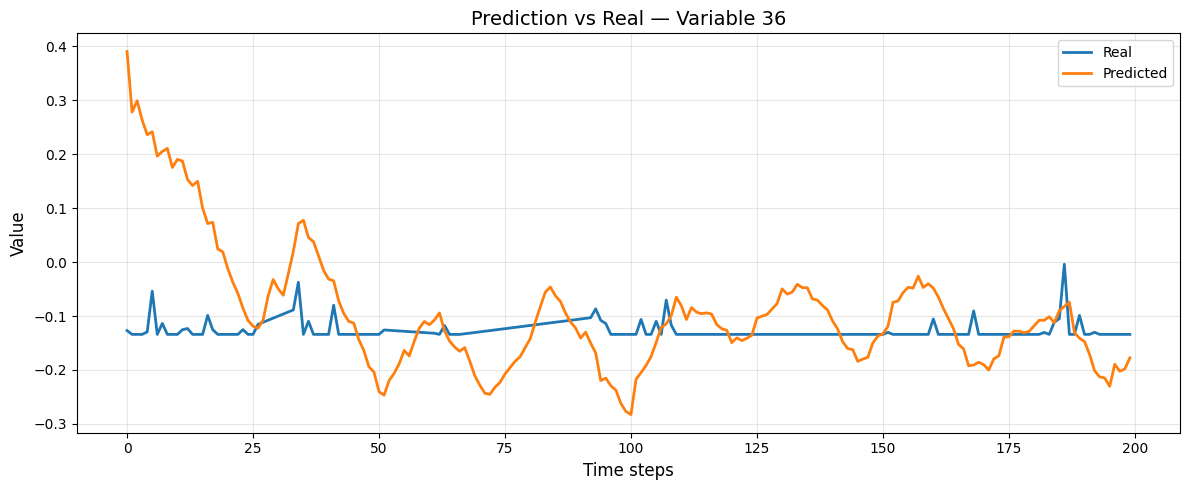

In [10]:
# Codeblock Q010: Graph Single Variable

import matplotlib.pyplot as plt

# Choose which variable to plot (0 = CO(GT))
var_index = 36

plt.figure(figsize=(12, 5))
plt.plot(true[:200, 0, var_index], label='Real', linewidth=2)
plt.plot(pred[:200, 0, var_index], label='Predicted', linewidth=2)

plt.title(f"Prediction vs Real — Variable {var_index}", fontsize=14)
plt.xlabel("Time steps", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

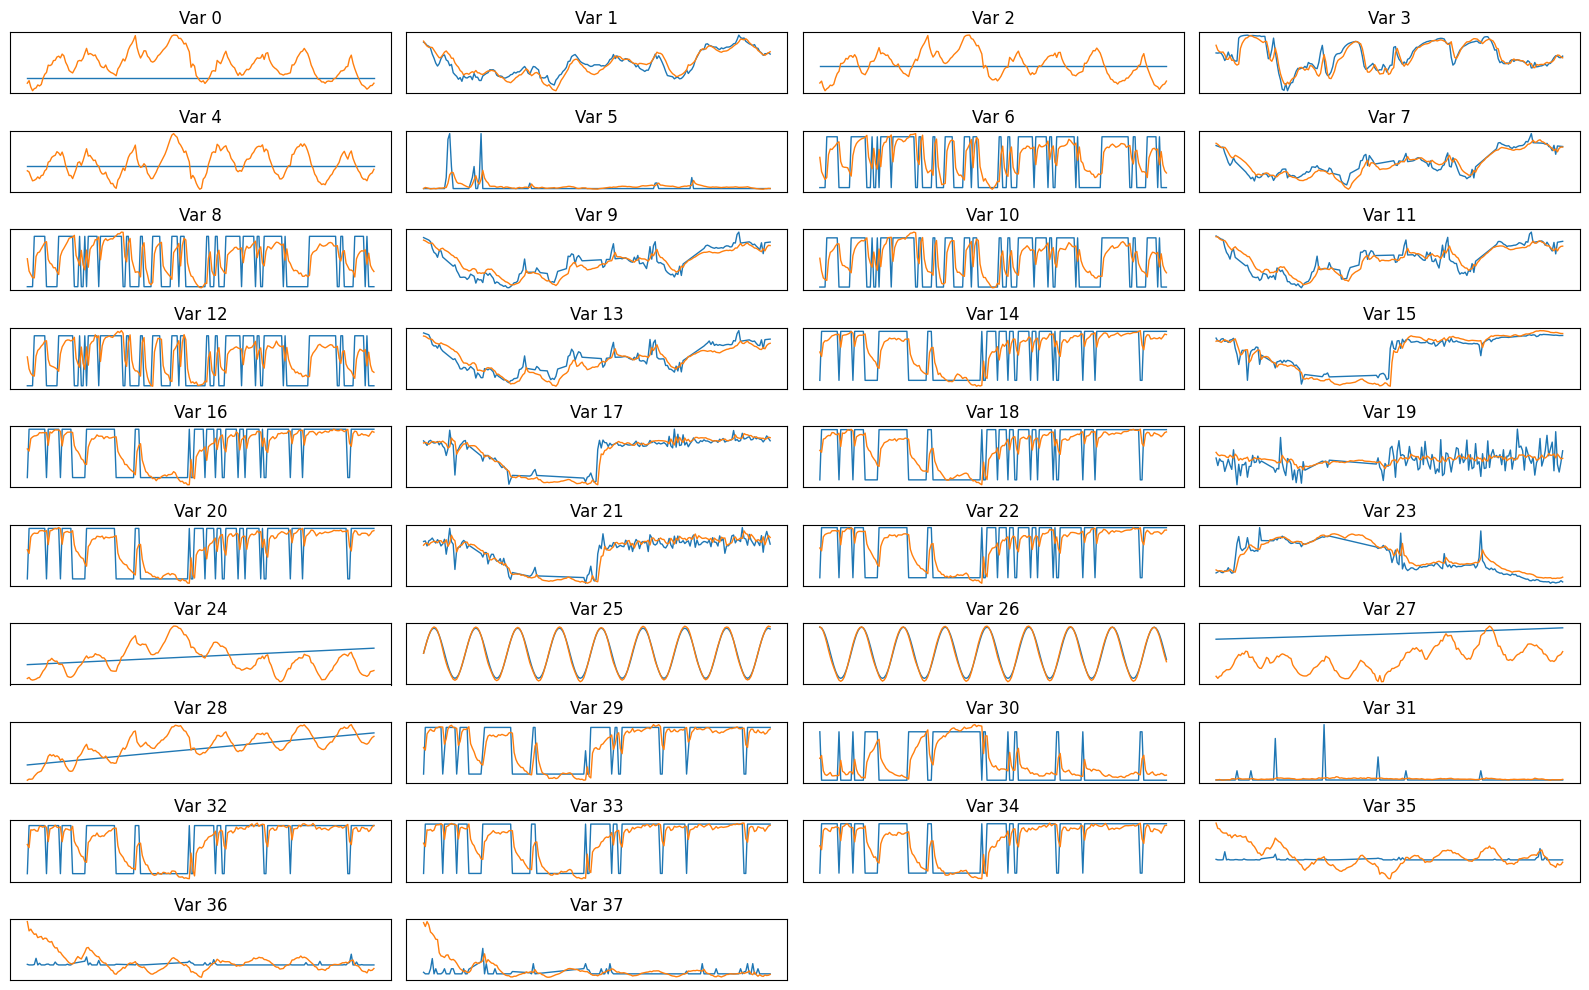

In [11]:
# Codeblock Q011: Graph all variables

num_vars = pred.shape[-1]
cols = 4
rows = int(np.ceil(num_vars / cols))

plt.figure(figsize=(16, 10))

for i in range(num_vars):
    plt.subplot(rows, cols, i+1)
    plt.plot(true[:200, 0, i], label='Real', linewidth=1)
    plt.plot(pred[:200, 0, i], label='Pred', linewidth=1)
    plt.title(f"Var {i}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [12]:
#@title Variable Names
import pandas as pd

# Load your dataset
df = pd.read_csv("./datasets/Model_Ready_Imputed_Rockfall_Data.csv")

# Drop timestamp if present
if df.columns[0].lower() in ["timestamp", "time", "date"]:
    df_numeric = df.iloc[:, 1:]
else:
    df_numeric = df

print("=== Model Variable Index Mapping ===")
for model_idx, col_name in enumerate(df_numeric.columns):
    csv_idx = df.columns.get_loc(col_name)
    print(f"Model index {model_idx:2d}  |  CSV index {csv_idx:2d}  |  {col_name}")

=== Model Variable Index Mapping ===
Model index  0  |  CSV index  1  |  Air_Temp_Real
Model index  1  |  CSV index  2  |  Air_Temp_Kalman
Model index  2  |  CSV index  3  |  Relative_Humidity_Real
Model index  3  |  CSV index  4  |  Relative_Humidity_Kalman
Model index  4  |  CSV index  5  |  Hourly_Rainfall_Real
Model index  5  |  CSV index  6  |  Hourly_Rainfall_Kalman
Model index  6  |  CSV index  7  |  TA_Real
Model index  7  |  CSV index  8  |  TA_Kalman
Model index  8  |  CSV index  9  |  Tmean_Real
Model index  9  |  CSV index 10  |  Tmean_Kalman
Model index 10  |  CSV index 11  |  Tmin_Real
Model index 11  |  CSV index 12  |  Tmin_Kalman
Model index 12  |  CSV index 13  |  Tmax_Real
Model index 13  |  CSV index 14  |  Tmax_Kalman
Model index 14  |  CSV index 15  |  Ref_Mean_Real
Model index 15  |  CSV index 16  |  Ref_Mean_Kalman
Model index 16  |  CSV index 17  |  Ref_Max_Real
Model index 17  |  CSV index 18  |  Ref_Max_Kalman
Model index 18  |  CSV index 19  |  Ref_Min_Real


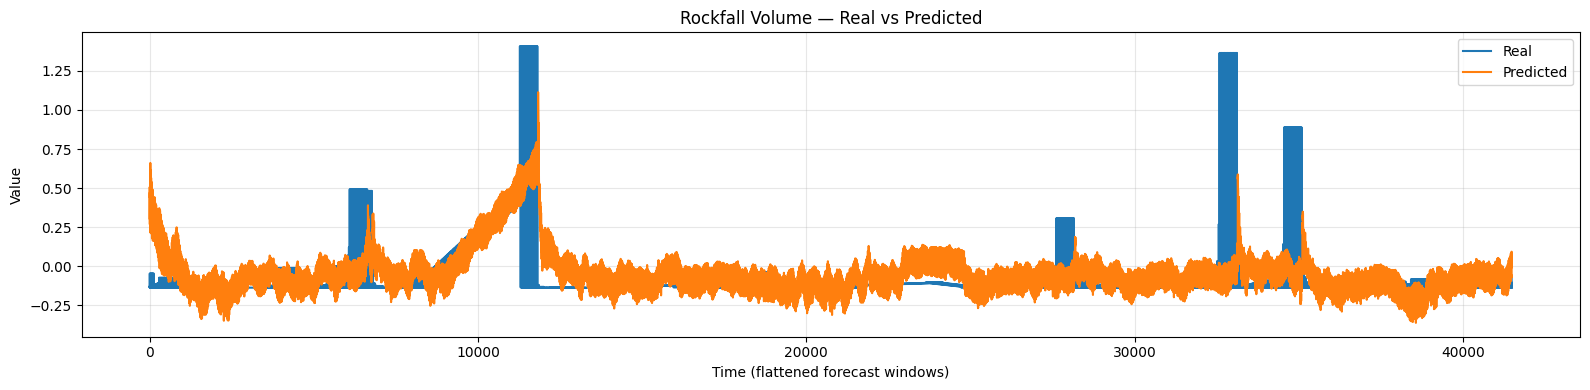

In [13]:
import matplotlib.pyplot as plt
import numpy as np

v = 35  # Rockfall Volume (model index)

true_series = true[:, :, v].reshape(-1)
pred_series = pred[:, :, v].reshape(-1)

plt.figure(figsize=(16, 4))
plt.plot(true_series, label="Real", linewidth=1.5)
plt.plot(pred_series, label="Predicted", linewidth=1.5)
plt.title("Rockfall Volume — Real vs Predicted")
plt.xlabel("Time (flattened forecast windows)")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

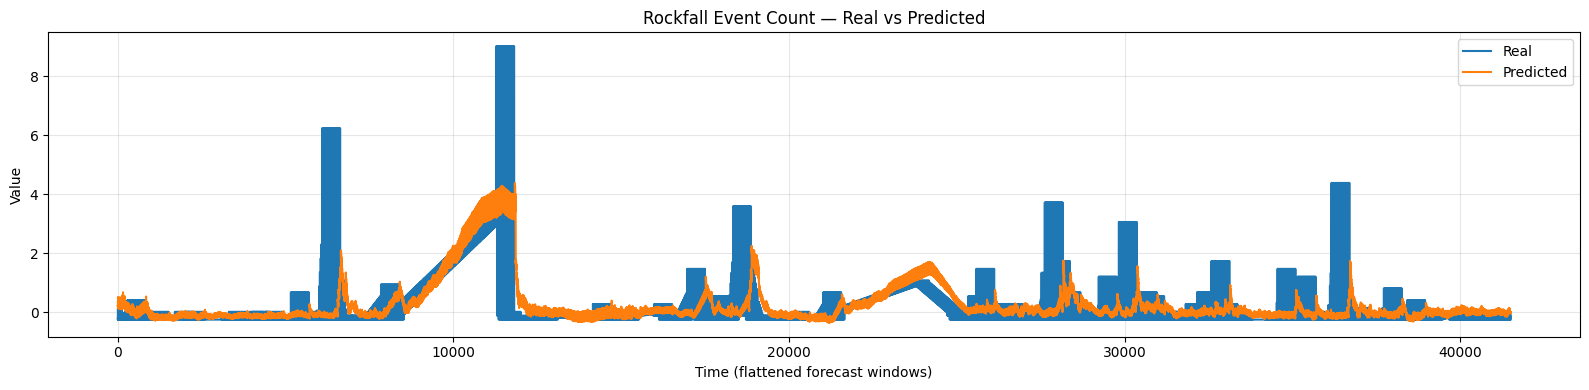

In [ ]:
v = 37  # Rockfall Event Count (model index)

true_series = true[:, :, v].reshape(-1)
pred_series = pred[:, :, v].reshape(-1)

plt.figure(figsize=(16, 4))
plt.plot(true_series, label="Real", linewidth=1.5)
plt.plot(pred_series, label="Predicted", linewidth=1.5)
plt.title("Rockfall Event Count — Real vs Predicted")
plt.xlabel("Time (flattened forecast windows)")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

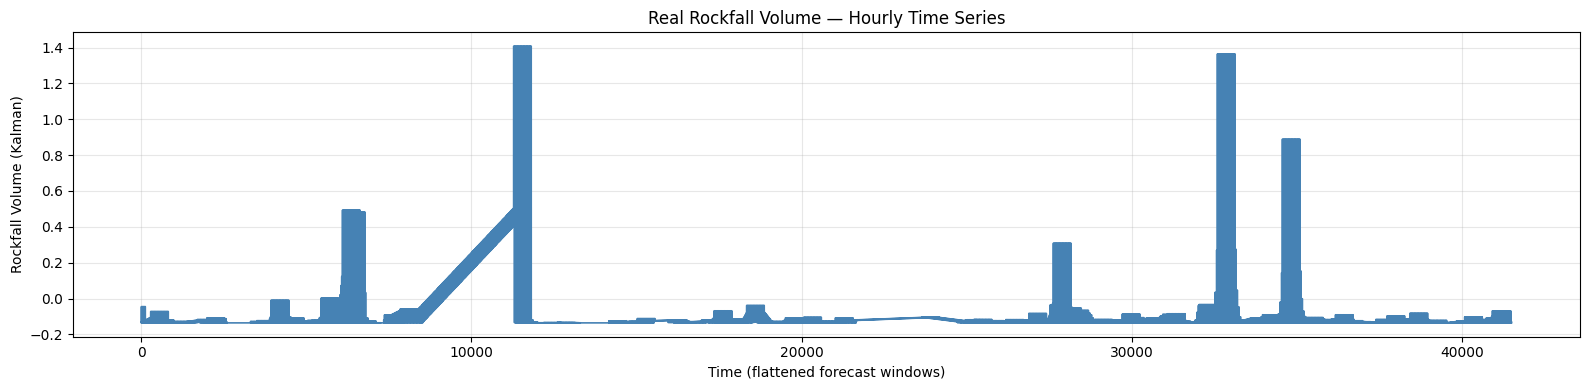

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

v = 35  # Rockfall Volume (model index)

# Flatten into a continuous timeline
real_volume = true[:, :, v].reshape(-1)

plt.figure(figsize=(16, 4))
plt.plot(real_volume, linewidth=1.2, color='steelblue')
plt.title("Real Rockfall Volume — Hourly Time Series")
plt.xlabel("Time (flattened forecast windows)")
plt.ylabel("Rockfall Volume (Kalman)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Variables
vol_idx = 35
evt_idx = 37

# Flatten into continuous hourly series
real_vol = true[:, :, vol_idx].reshape(-1)
pred_vol = pred[:, :, vol_idx].reshape(-1)

real_evt = true[:, :, evt_idx].reshape(-1)
pred_evt = pred[:, :, evt_idx].reshape(-1)

# Build a dataframe
df = pd.DataFrame({
    "Real_Volume": real_vol,
    "Pred_Volume": pred_vol,
    "Real_EventCount": real_evt,
    "Pred_EventCount": pred_evt
})

# Show the first few hours
df.head(20)

,Real_Volume,Pred_Volume,Real_EventCount,Pred_EventCount
0,-0.130063,0.115095,-0.200803,0.217548
1,-0.136004,0.171774,-0.240978,0.210971
2,-0.136004,0.065967,-0.240978,0.202396
3,-0.136004,0.136866,-0.240978,0.386791
4,-0.134205,0.134886,-0.108660,0.318266
5,-0.045081,0.194719,0.155977,0.391893
6,-0.136004,0.159744,-0.240978,0.367153
7,-0.130048,0.259348,-0.108660,0.322857
8,-0.136004,0.123181,-0.240978,0.352797
9,-0.136004,0.182098,-0.240978,0.340229


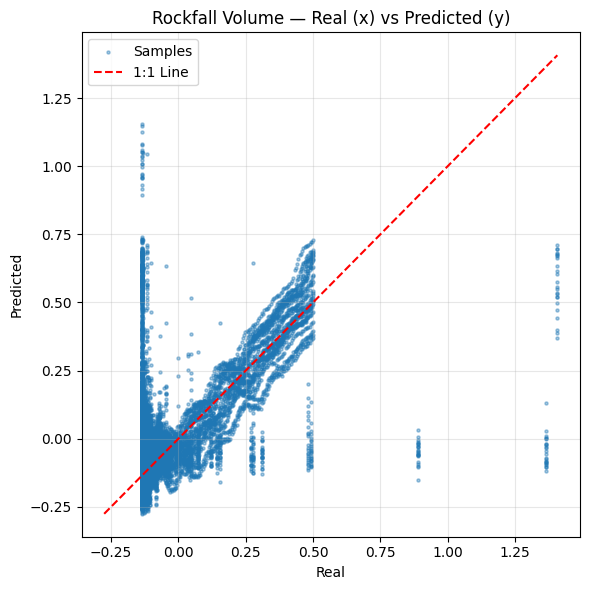

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

v = 35  # Rockfall Volume (model index)

true_series = true[:, :, v].reshape(-1)
pred_series = pred[:, :, v].reshape(-1)

plt.figure(figsize=(6, 6))
plt.scatter(true_series, pred_series, s=5, alpha=0.4, label="Samples")

# 1:1 reference line
min_val = min(true_series.min(), pred_series.min())
max_val = max(true_series.max(), pred_series.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

plt.title("Rockfall Volume — Real (x) vs Predicted (y)")
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

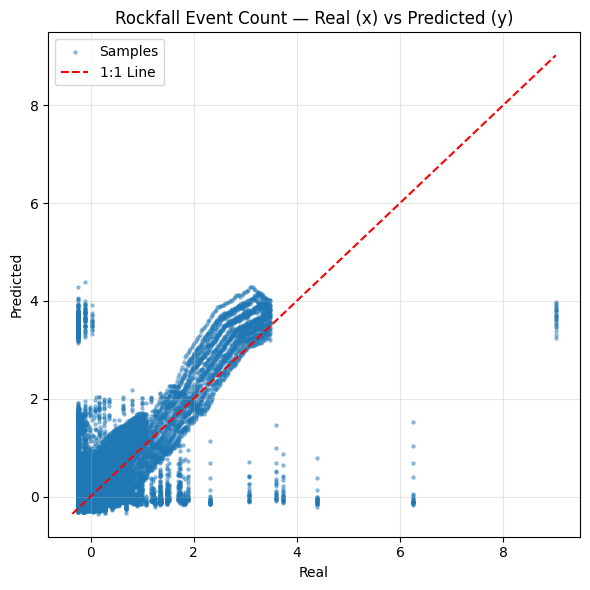

In [ ]:
v = 37  # Rockfall Event Count (model index)

true_series = true[:, :, v].reshape(-1)
pred_series = pred[:, :, v].reshape(-1)

plt.figure(figsize=(6, 6))
plt.scatter(true_series, pred_series, s=5, alpha=0.4, label="Samples")

# 1:1 reference line
min_val = min(true_series.min(), pred_series.min())
max_val = max(true_series.max(), pred_series.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

plt.title("Rockfall Event Count — Real (x) vs Predicted (y)")
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()